# Classification Track — Part A
## 01. Logistic Regression (Baseline Classifier)

**Notes from the algorithm list:** Baseline classifier; interpret coefficients/odds.

Logistic Regression is used here as the **baseline** model against which every other Part-A and Part-B algorithm
will be compared. It models the log-odds of each class as a linear combination of the input features
(multinomial / softmax formulation for our 7-class problem).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
import os

RANDOM_STATE = 42
sns.set_style("whitegrid")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")
class_map = pd.read_csv("../data/processed/class_mapping.csv", index_col=0)["class_name"].to_dict()
class_names = [class_map[i] for i in sorted(class_map.keys())]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", class_names)

X_train: (1688, 21)  X_test: (423, 21)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [2]:
ALGO_KEY = "logistic_regression"
ALGO_DISPLAY = "Logistic Regression"

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
print("Model trained.")

Model trained.


### Coefficient interpretation

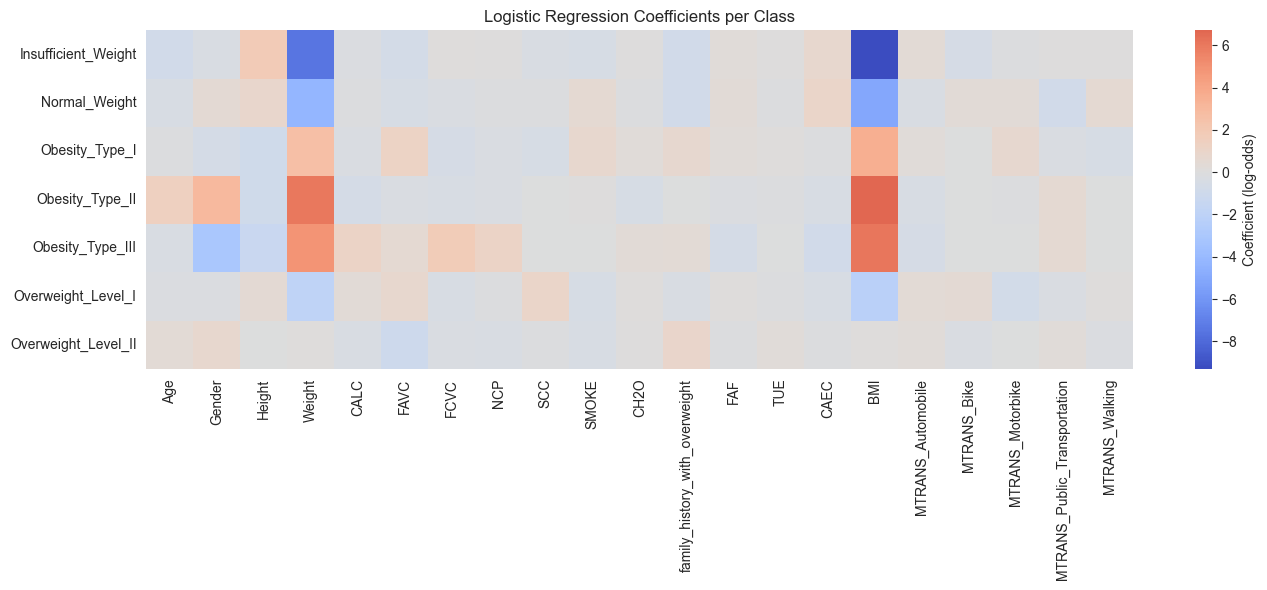

Top 3 positive drivers for 'Obesity_Type_III':
BMI       6.127798
Weight    4.901259
FCVC      1.774944
Name: Obesity_Type_III, dtype: float64


In [3]:
coef_df = pd.DataFrame(log_reg.coef_, columns=X_train.columns, index=class_names)
plt.figure(figsize=(14, 6))
sns.heatmap(coef_df, cmap="coolwarm", center=0, annot=False, cbar_kws={"label": "Coefficient (log-odds)"})
plt.title("Logistic Regression Coefficients per Class")
plt.tight_layout()
plt.savefig("../results/fig_logreg_coefficients.png", bbox_inches="tight")
plt.show()

print("Top 3 positive drivers for 'Obesity_Type_III':")
print(coef_df.loc["Obesity_Type_III"].sort_values(ascending=False).head(3))

**Interpretation:** each coefficient is the change in log-odds of a class relative to the reference class for
a one-unit increase in that (scaled) feature. As expected, `BMI` and `Weight` carry the largest positive coefficients
for the higher obesity classes (`Obesity_Type_I/II/III`) and the largest negative coefficients for
`Insufficient_Weight` — confirming the engineered `BMI` feature is doing useful work even in a purely linear model.

### Evaluation

In [4]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(class_map.keys()))
roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1-score   : {f1_weighted:.4f}")
print(f"ROC-AUC (OvR, wtd)  : {roc_auc_ovr:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Accuracy           : 0.9078
Weighted Precision  : 0.9088
Weighted Recall     : 0.9078
Weighted F1-score   : 0.9071
ROC-AUC (OvR, wtd)  : 0.9921

Full classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.98      0.95        54
      Normal_Weight       0.84      0.74      0.79        58
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.77      0.84      0.80        58
Overweight_Level_II       0.92      0.84      0.88        58

           accuracy                           0.91       423
          macro avg       0.91      0.91      0.90       423
       weighted avg       0.91      0.91      0.91       423



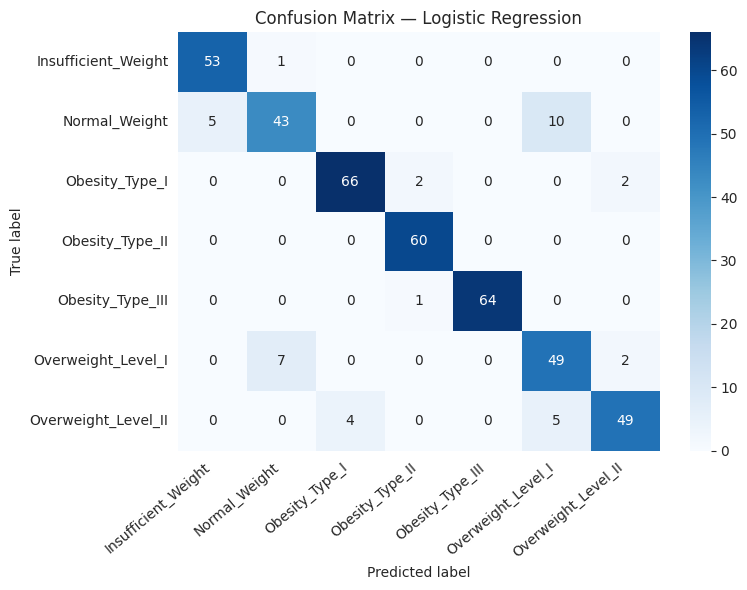

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — {ALGO_DISPLAY}")
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../results/fig_confusion_matrix_{ALGO_KEY}.png", bbox_inches="tight")
plt.show()

In [5]:
results_path = "../results/part_a_results.csv"
row = pd.DataFrame([{
    "Algorithm": ALGO_DISPLAY,
    "Accuracy": round(acc, 4),
    "Precision_weighted": round(precision_weighted, 4),
    "Recall_weighted": round(recall_weighted, 4),
    "F1_weighted": round(f1_weighted, 4),
    "ROC_AUC_OvR": round(roc_auc_ovr, 4),
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Algorithm"] != ALGO_DISPLAY]
    combined = pd.concat([existing, row], ignore_index=True)
else:
    combined = row

combined.to_csv(results_path, index=False)
print("Logged result to part_a_results.csv:")
combined

Logged result to part_a_results.csv:


,Algorithm,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_OvR
0,K-Nearest Neighbors,0.9243,0.9230,0.9243,0.9229,0.9864
1,Naive Bayes (Gaussian),0.7447,0.7849,0.7447,0.7351,0.9497
2,Decision Tree,0.9811,0.9814,0.9811,0.9810,0.9955
3,Support Vector Machine (SVC),0.9764,0.9773,0.9764,0.9765,0.9989
4,Logistic Regression,0.9078,0.9088,0.9078,0.9071,0.9921
